In [1]:
from rsm3d.data_io import RSMDataloader_CMS
from rsm3d.rsm3d import RSMBuilder  # <-- 4-circle xrayutilities builder
from rsm3d.data_viz import RSMNapariViewer
setup_file = './cms_setup.yaml'
tiff_dir  = '/nsls2/data/staff/xyang4/data_cs/cms_rsm3d/2022_3/stitched3/'
crop_region = ((624, 1624), (230, 1230))  # Example crop region (y, x)
loader = RSMDataloader_CMS(
    setup_file,
    tiff_dir,
    crop_window=crop_region,
    selected_scans=list(range(796715, 796725)),
)

In [ ]:
builder = RSMBuilder(loader,
                     sample_axes = ('z-', 'y+', 'x+'),
                     detector_axes = ('z-',),
                     )
print("Building RSM...")
Q_samp, hkl, intensity = builder.compute_full()

(1000, 1000)


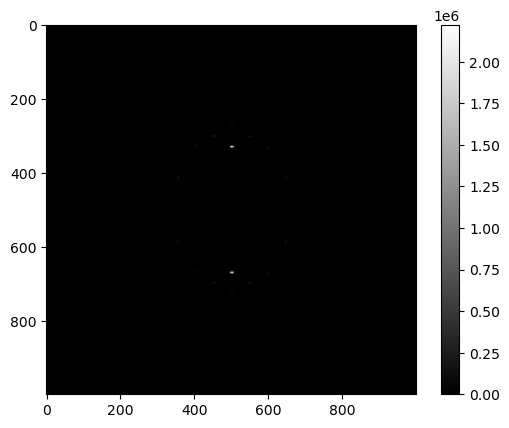

In [2]:
import matplotlib.pyplot as plt
print(frames_df.intensity[1].shape)
plt.imshow(frames_df.intensity[1], cmap='gray')
plt.colorbar()
plt.show()

In [ ]:
# Convert the frames dictionary into lists of names and arrays
image_names = list(frames.keys())
image_stack = [frames[name] for name in image_names]

print(f"Collected {len(image_stack)} images")
print(f"First image: {image_names[0]}, shape={image_stack[0].shape}, dtype={image_stack[0].dtype}")

In [ ]:
import numpy as np
import pandas as pd

# Assign omega values starting at 0 with 0.5° increments
omega = np.arange(len(image_stack), dtype=float) * 0.5

# Build a DataFrame with the requested columns
frames_df = pd.DataFrame({
    "frame_index": np.arange(len(image_stack)),
    "image_stack": image_stack,
    "omega_deg": omega,
})

frames_df.head()

In [ ]:
print(f"First frame omega: {frames_df.loc[0, 'omega_deg']} deg")

In [ ]:
import numpy as np
import xrayutilities as xu

# Instrument geometry parameters
wavelength_A = 0.9184          # Angstroms
pixel_size_m = 0.172e-3        # meters
sample_detector_distance_m = 3.03  # meters
beam_center = (733, 1679 - 553)    # (row, col) in pixels

# Prepare xrayutilities conversion (sample axes defined outer→inner)
sample_axes = ['z-', 'y-', 'x+']
detector_axes = ['z+']
beam_direction = (0, 1, 0)  # +Y

ny, nx = frames_df.loc[0, 'image_stack'].shape
qconv = xu.experiment.QConversion(sample_axes, detector_axes, beam_direction, wl=wavelength_A)
qconv.init_area(
    'z-', 'x+',
    cch1=beam_center[0],
    cch2=beam_center[1],
    Nch1=ny,
    Nch2=nx,
    distance=sample_detector_distance_m,
    pwidth1=pixel_size_m,
    pwidth2=pixel_size_m,
    detrot=0.0,
    tiltazimuth=0.0,
    tilt=0.0,
)


def compute_q_space(frame_row):
    """Return q-components and magnitude grids for a single frame."""
    omega_deg = float(frame_row.omega_deg)
    qx, qy, qz = qconv.area(omega_deg, 0.0, 0.0, 0.0, deg=True)
    q_mag = np.sqrt(qx**2 + qy**2 + qz**2)
    return {
        "frame_index": int(frame_row.frame_index),
        "omega_deg": omega_deg,
        "qx": qx,
        "qy": qy,
        "qz": qz,
        "q_mag": q_mag,
        "intensity": frame_row.image_stack,
    }

# Convert every frame in the stack to Q-space coordinates
q_space_frames = [compute_q_space(row) for row in frames_df.itertuples(index=False)]

example = q_space_frames[0]
print(
    f"Frame {example['frame_index']}: q-grid shape = {example['qx'].shape}, "
    f"intensity shape = {example['intensity'].shape}"
)
